In [431]:
import xarray as xr
import autoroot
from satpy.scene import Scene
from pyhdf.SD import SD, SDC 
import pandas as pd
import cartopy.crs as ccrs
from pyproj import CRS, Transformer
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
from pyresample import create_area_def
import os
from rs_tools._src.geoprocessing.match import match_timestamps_af
from rs_tools._src.utils.io import get_list_filenames
from pathlib import Path
from copy import deepcopy


### (0=Cloudy, 1=Uncertain, 2=Probably Clear, 3=Confident Clear)

In [48]:
modis_cm_path =  '/mnt/data8tb/fire_detection/modis/CM'

In [380]:
files = [os.path.join(modis_cm_path, i) for i in os.listdir(modis_cm_path) if i.endswith('.hdf')]

In [50]:
len(files)

4716

In [451]:
def load_modis_cm(file):
    scn = Scene(
                reader="modis_l2",
                filenames=[file]
            )
    # Load cloud mask data
    datasets = scn.available_dataset_names()
    # Needs to be loaded at 1000 m resolution for all channels to match
    scn.load(datasets, generate=False, resolution=1000)
    return scn

In [452]:
scn = load_modis_cm(files[0])
cloud_masks = scn['cloud_mask']
cloud_masks = cloud_masks+1

In [419]:
np.unique(cloud_masks)

array([1, 2, 3, 4], dtype=uint8)

In [433]:
scn_copy = deepcopy(scn)
scn_copy['cloud_mask'] = scn_copy['cloud_mask'] + 1

In [442]:
scn

In [441]:
scn_copy

In [453]:
latitudes_cm = scn['latitude']
longitudes_cm = scn['longitude']
area_extent = [np.nanmin(longitudes_cm.values), np.nanmin(latitudes_cm.values), np.nanmax(longitudes_cm.values), np.nanmax(latitudes_cm.values)]  # [min_lon, min_lat, max_lon, max_lat]
area_def = create_area_def('my_area',
                        {'proj': 'longlat', 'datum': 'WGS84'},
                        area_extent=area_extent,
                        resolution=0.027,
                        units='degrees',
                        description='Gloxx bal degree lat-lon grid')
new_scn_cloud = scn.resample(area_def, fill_value = 900)
ds_resampled_clouds = scn.to_xarray_dataset()
cloud_mask_data = ds_resampled_clouds['cloud_mask']

Rounding shape to (795, 1143) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026981268654970986, 0.026971836210046923) meters


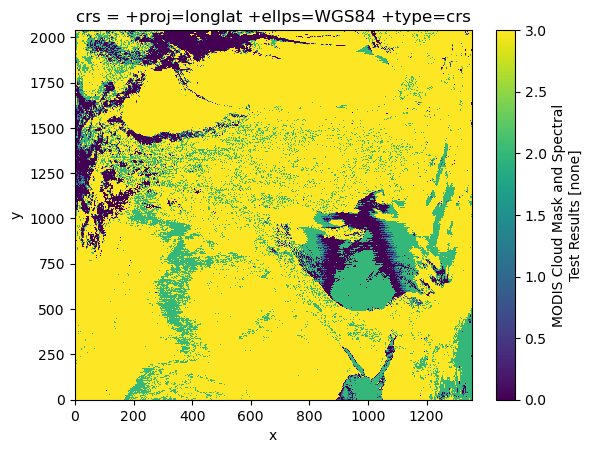

In [454]:
cloud_mask_data.plot()

In [52]:
for i, file in enumerate(files):   
    out_path = file[:-3] + '.tif'
    if os.path.exists(out_path):
        continue
    if i % 100 == 0:
        print(f'Processing file {i+1} of {len(files)}: {file}')
    try:
        scn = load_modis_cm(file)
        latitudes_cm = scn['latitude']
        longitudes_cm = scn['longitude']
        cloud_masks = scn['cloud_mask']
        area_extent = [np.nanmin(longitudes_cm.values), np.nanmin(latitudes_cm.values), np.nanmax(longitudes_cm.values), np.nanmax(latitudes_cm.values)]  # [min_lon, min_lat, max_lon, max_lat]
        area_def = create_area_def('my_area',
                            {'proj': 'longlat', 'datum': 'WGS84'},
                            area_extent=area_extent,
                            resolution=0.027,
                            units='degrees',
                            description='Gloxx bal degree lat-lon grid')
        new_scn_cloud = scn.resample(area_def)
        ds_resampled_clouds = new_scn_cloud.to_xarray_dataset()
        cloud_mask_data = ds_resampled_clouds['cloud_mask']
        
        cloud_mask_data.rio.to_raster(out_path)
    except Exception as e:
        print(f'Error processing file {file}: {e}')
        continue

Processing file 1 of 4716: /mnt/data8tb/fire_detection/modis/CM/MYD35_L2.A2024226.1125.061.2024227152541.hdf


Rounding shape to (795, 1143) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026981268654970986, 0.026971836210046923) meters
Rounding shape to (781, 970) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.026995353600413528, 0.0269668398379669) meters
Rounding shape to (787, 1078) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.026998944539086054, 0.02697314755586384) meters
Rounding shape to (807, 1393) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026984670054373428, 0.026982294434803863) meters
Rounding shape to (794, 1200) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026999605496724446, 0.026982874353826798) meters
Rounding shape to (795, 1188) and resolution from (0.027000000000000135, 0.027000000000001023) meters to (0.02698818842569987, 0.026972292054374264) meters
Rounding shape to (818, 1569) and resolution from (0.0270000000

Processing file 101 of 4716: /mnt/data8tb/fire_detection/modis/CM/MYD35_L2.A2024189.1235.061.2024190151128.hdf


Rounding shape to (793, 1166) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.02698087670215714, 0.026985442653429913) meters
Rounding shape to (790, 1119) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.026985051484913352, 0.026991189884234077) meters
Rounding shape to (788, 1086) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.026985160553652937, 0.026980276640296588) meters
Rounding shape to (804, 1299) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026986519312106067, 0.026981330036523924) meters
Rounding shape to (827, 1703) and resolution from (0.027000000000000135, 0.027000000000001023) meters to (0.02699261305266384, 0.026981718162527396) meters
Rounding shape to (784, 1018) and resolution from (0.02700000000000058, 0.027000000000001023) meters to (0.02698851381163232, 0.026967446414791808) meters
Rounding shape to (831, 1750) and resolution from (0.027000000

Processing file 301 of 4716: /mnt/data8tb/fire_detection/modis/CM/MYD35_L2.A2024274.1415.061.2024296182343.hdf


...

Rounding shape to (813, 1497) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.02698946222115455, 0.026974184193441057) meters
Rounding shape to (794, 1127) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026991999879175305, 0.02698768356284807) meters
Rounding shape to (784, 1027) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.02697568185837847, 0.02698363819900824) meters
Rounding shape to (781, 1003) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026979900190861134, 0.026987100227541562) meters
Rounding shape to (825, 1676) and resolution from (0.027000000000000024, 0.027000000000001023) meters to (0.026993481811304936, 0.026991022283380683) meters
Rounding shape to (782, 994) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.02698413323108819, 0.02698508065070033) meters
Rounding shape to (781, 984) and resolution from (0.0270000000000

Processing file 4501 of 4716: /mnt/data8tb/fire_detection/modis/CM/MYD35_L2.A2024177.1100.061.2024178150909.hdf


Rounding shape to (797, 1229) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026978901676087966, 0.02699224263840966) meters
Rounding shape to (795, 1158) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026979476059039022, 0.026986706331840853) meters
Rounding shape to (788, 1040) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.02697591629738991, 0.026989179214245172) meters
Rounding shape to (794, 1180) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026992881096015543, 0.026988192829737436) meters
Rounding shape to (820, 1591) and resolution from (0.02699999999999747, 0.027000000000001023) meters to (0.02698907216789586, 0.026997933736661584) meters
Rounding shape to (814, 1490) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026993328452910352, 0.026977604671543882) meters
Rounding shape to (795, 1208) and resolution from (0.027000000

Processing file 4701 of 4716: /mnt/data8tb/fire_detection/modis/CM/MYD35_L2.A2023242.0910.061.2023242214146.hdf


Rounding shape to (803, 1344) and resolution from (0.02700000000000813, 0.027000000000001023) meters to (0.026982619648887998, 0.026997215869566275) meters
Rounding shape to (821, 1618) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.026988163277304217, 0.026974384154530014) meters
Rounding shape to (821, 1615) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.026997876241111166, 0.026991338880866512) meters
Rounding shape to (786, 1070) and resolution from (0.027000000000000024, 0.02699999999999747) meters to (0.026979826098290558, 0.026983887184667224) meters
Rounding shape to (807, 1400) and resolution from (0.027000000000001023, 0.027000000000001023) meters to (0.02699216161455427, 0.026984624850853373) meters
Rounding shape to (822, 1630) and resolution from (0.026999999999999247, 0.027000000000001023) meters to (0.026996986997639475, 0.026971199796727685) meters
Rounding shape to (784, 1030) and resolution from (0.02699999

## Find the msg geoprocessed file

In [ ]:
modis_cm_path = '/mnt/data8tb/fire_detection/modis/CM'
f_21_24_path = "/mnt/data8tb/msg_2020/geoprocessed"

In [174]:
cm_files = [ i for i in os.listdir(modis_cm_path) if i.endswith('.tif')]

In [175]:
cm_df = pd.DataFrame({'name': cm_files})

In [176]:
pat = r'\.A(?P<y>\d{4})(?P<doy>\d{3})\.(?P<hh>\d{2})(?P<mm>\d{2})'
parts = cm_df['name'].str.extract(pat)

# to numeric
parts = parts.apply(pd.to_numeric, errors='coerce')

In [177]:
cm_df['datetime'] = (
    pd.to_datetime(parts['y'], format='%Y')
    + pd.to_timedelta(parts['doy'] - 1, unit='D')
    + pd.to_timedelta(parts['hh'], unit='h')
    + pd.to_timedelta(parts['mm'], unit='m')
)

In [178]:
cm_df

,name,datetime
0,MYD35_L2.A2022271.1130.061.2022272152616..tif,2022-09-28 11:30:00
1,MYD35_L2.A2023243.1445.061.2023244152616..tif,2023-08-31 14:45:00
2,MYD35_L2.A2021244.1255.061.2021245151242..tif,2021-09-01 12:55:00
3,MYD35_L2.A2020256.1120.061.2020257150247..tif,2020-09-12 11:20:00
4,MYD35_L2.A2021236.1340.061.2021237191801..tif,2021-08-24 13:40:00
...,...,...
4712,MYD35_L2.A2023212.1245.061.2023213152718..tif,2023-07-31 12:45:00
4713,MYD35_L2.A2022259.1425.061.2022260152944..tif,2022-09-16 14:25:00
4714,MYD35_L2.A2021230.1235.061.2021231153044..tif,2021-08-18 12:35:00
4715,MYD35_L2.A2020180.1055.061.2020182161307..tif,2020-06-28 10:55:00


In [179]:
cm_df['utimes'] = cm_df['datetime'].dt.strftime('%Y%m%d%H%M00')

In [180]:
len(cm_df.utimes.unique())

4717

In [181]:
unique_times_cm = cm_df['datetime'].dt.strftime('%Y%m%d%H%M00').unique().tolist()

In [182]:
files_msg = get_list_filenames(f_21_24_path, ".nc")

In [183]:
def convert_lat_lon_to_x_y(crs, lon, lat):
    transformer = Transformer.from_crs(CRS("+proj=latlon"), crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return x, y
def parse_af_dates_from_file(file):
    timestamp = Path(file).name.split("_")[0]
    return timestamp

In [184]:
unique_times_msg = list(set(map(parse_af_dates_from_file, files_msg)))

In [185]:
unique_times_msg

['20200929155743',
 '20200929162743',
 '20200929184242',
 '20200929085742',
 '20200928221243',
 '20200929131243',
 '20200929172743',
 '20200929205743',
 '20200928144243',
 '20200928154243',
 '20200929044243',
 '20200930191242',
 '20200928124243',
 '20200930005742',
 '20200930181244',
 '20200930225743',
 '20200930172743',
 '20200930095743',
 '20200928142743',
 '20200929114243',
 '20200928231243',
 '20200928171242',
 '20200928152743',
 '20200929195742',
 '20200930074243',
 '20200930025742',
 '20200930045743',
 '20200930165743',
 '20200930142743',
 '20200929074243',
 '20200929182742',
 '20200928174242',
 '20200929141243',
 '20200930161242',
 '20200928204243',
 '20200928232742',
 '20200930192743',
 '20200929055743',
 '20200929171243',
 '20200928135743',
 '20200930234243',
 '20200929064243',
 '20200930065742',
 '20200928111242',
 '20200930212742',
 '20200929034242',
 '20200930164243',
 '20200930174243',
 '20200929081243',
 '20200930152742',
 '20200928114242',
 '20200929092742',
 '2020092900

In [186]:
df_matches = match_timestamps_af(unique_times_cm, unique_times_msg, cutoff=15)
df_matches.columns = ['timestamp_cm', 'timestamp_msg']

No valid af mask found for 2022-09-28 11:30:00
No valid af mask found for 2023-08-31 14:45:00
No valid af mask found for 2021-09-01 12:55:00
No matching af mask found for 2020-09-12 11:20:00
No valid af mask found for 2021-08-24 13:40:00
No valid af mask found for 2021-07-29 09:45:00
No valid af mask found for 2022-07-14 09:40:00
No valid af mask found for 2024-07-30 13:30:00
No valid af mask found for 2024-08-16 11:50:00
No valid af mask found for 2024-08-29 14:00:00
No valid af mask found for 2024-09-04 14:45:00
No valid af mask found for 2024-09-20 14:05:00
No valid af mask found for 2021-09-13 11:35:00
No valid af mask found for 2023-08-19 09:45:00
No valid af mask found for 2023-08-24 14:50:00
No valid af mask found for 2022-06-17 11:45:00
No matching af mask found for 2020-09-16 11:00:00
No valid af mask found for 2021-08-29 12:20:00
No valid af mask found for 2021-07-24 14:25:00
No valid af mask found for 2021-09-12 12:35:00
No matching af mask found for 2020-06-08 09:45:00
No v

In [187]:
df_matches

,timestamp_cm,timestamp_msg
0,20200930093000,20200930094243
1,20200928095000,20200928105742
2,20200928112000,20200928112742
3,20200930142500,20200930142743
4,20200930125000,20200930125743
5,20200928094000,20200928105742
6,20200930111500,20200930112743
7,20200930125500,20200930125743
8,20200929135000,20200929135743
9,20200928112500,20200928112742


In [247]:
msg_im = xr.open_dataset(os.path.join(f_21_24_path, '20200929121242_msg.nc'))
modis_im = rioxarray.open_rasterio(os.path.join(modis_cm_path, cm_df[cm_df['utimes'] == '20200929120500'].name.values[0]))

In [249]:
ymax_msg, ymin_msg, xmax_msg, xmin_msg = msg_im.latitude.values.max(), msg_im.latitude.values.min(), msg_im.longitude.values.max(), msg_im.longitude.values.min()
lonmax_modis, lonmin_modis = modis_im.x.max().item(), modis_im.x.min().item()
latmax_modis, latmin_modis = modis_im.y.max().item(), modis_im.y.min().item()

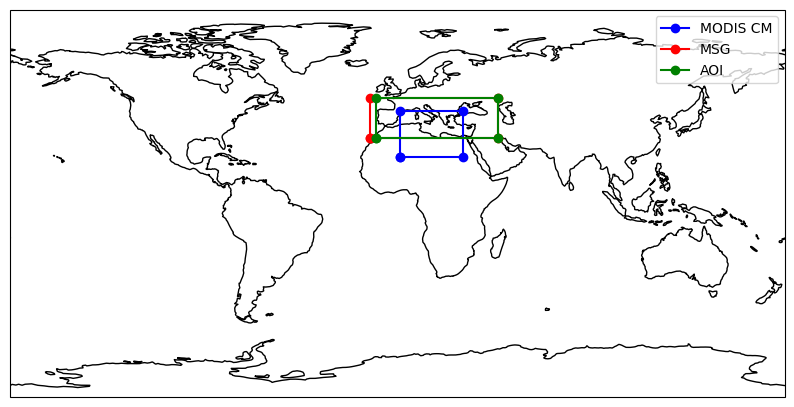

In [250]:
#plot the bounds of the modis image and the msg image on a universal map
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
# Plot MODIS bounds
modis_bounds = [[lonmin_modis, latmin_modis], [lonmax_modis, latmin_modis], [lonmax_modis, latmax_modis], [lonmin_modis, latmax_modis], [lonmin_modis, latmin_modis]]
ax.plot(*zip(*modis_bounds), color='blue', marker='o', transform=ccrs.PlateCarree(), label='MODIS CM')
# Plot MSG bounds
msg_bounds = [[xmin_msg, ymin_msg], [xmax_msg, ymin_msg], [xmax_msg, ymax_msg], [xmin_msg, ymax_msg], [xmin_msg, ymin_msg]]
ax.plot(*zip(*msg_bounds), color='red', marker='o', transform=ccrs.PlateCarree(), label='MSG')

aoi_bounds =  [[aoi_lon_min, aoi_lat_min], [aoi_lon_max, aoi_lat_min], [aoi_lon_max, aoi_lat_max], [aoi_lon_min, aoi_lat_max], [aoi_lon_min, aoi_lat_min]]
ax.plot(*zip(*aoi_bounds), color='green', marker='o', transform=ccrs.PlateCarree(), label='AOI')

plt.legend()
plt.show()

In [203]:
#check if they overlap and add a column to df_matches 
if not (lonmin_modis > xmax_msg or lonmax_modis < xmin_msg or latmin_modis > ymax_msg or latmax_modis < ymin_msg):
    print("They overlap")
else:
    print("No overlap")

They overlap


In [204]:
msg_im

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 410, x: 1235, band: 11, time: 1, band_wavelength: 11)
Coordinates:
  * y                   (y) float64 3kB 3.102e+06 3.105e+06 ... 4.33e+06
  * x                   (x) float64 10kB -9.331e+05 -9.301e+05 ... 2.769e+06
    cloud_mask          (y, x) float64 4MB ...
    latitude            (y, x) float32 2MB 30.24 30.24 30.24 ... 48.99 49.0
    longitude           (y, x) float32 2MB -10.0 -9.972 -9.939 ... 46.52 46.6
  * band                (band) <U6 264B 'IR_016' 'IR_039' ... 'WV_062' 'WV_073'
  * time                (time) <U19 76B '2020-09-30 09:30:00'
  * band_wavelength     (band_wavelength) float64 88B 1.64 3.92 ... 6.25 7.35
Data variables:
    msg_seviri_fes_3km  int64 8B ...
    Rad                 (band, y, x) float32 22MB ...
Attributes:
    calibration:         radiance
    standard_name:       toa_outgoing_radiance_per_unit_wavenumber
    platform_name:       Meteosat-11
    sensor:              seviri
    units:               mW m-2 sr-1 (cm-1)-1
    orbital_parameters:  {"projection_longitude": 0.0, "projection_latitude":...

In [251]:
def check_overlap(modis_im, msg_im):
    lonmax_modis, lonmin_modis = modis_im.x.max().item(), modis_im.x.min().item()
    latmax_modis, latmin_modis = modis_im.y.max().item(), modis_im.y.min().item()
    print(lonmin_modis, lonmax_modis, latmin_modis, latmax_modis)
    
    lonmax_msg, lonmin_msg = msg_im.x.max().item(), msg_im.x.min().item()
    latmax_msg, latmin_msg = msg_im.y.max().item(), msg_im.y.min().item()
    print(lonmin_msg, lonmax_msg, latmin_msg, latmax_msg)
    
    #check if they overlap and add a column to df_matches 
    if not (lonmin_modis > lonmax_msg or lonmax_modis < lonmin_msg or latmin_modis > latmax_msg or latmax_modis < latmin_msg):
        #print("They overlap")
        return True
    else:
        #print("No overlap")
        return False

In [140]:
overlap_bool = []
for index, row in df_matches.iterrows():
    patches = [i for i in os.listdir(f_21_24_path) if i.startswith(row['timestamp_msg'])]
    if len(patches) == 0:
        overlap_bool.append(False)
        continue
    for patch in patches:
        try:
            msg_im = rioxarray.open_rasterio(os.path.join(f_21_24_path, patch), masked=True).squeeze()
            modis_im = rioxarray.open_rasterio(os.path.join(modis_cm_path, cm_df[cm_df['utimes'] == row['timestamp_cm']]['name'].values[0]), masked=True).squeeze()
            if check_overlap(modis_im, msg_im):
                overlap_bool.append(True)
                print(f"Match found for {row['timestamp_cm']} and {patch}")
            else:
                overlap_bool.append(False)
        except Exception as e:
            print(f"Error processing {patch} or {row['timestamp_cm']}: {e}")
            continue

-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
1563210.0948486328 1656222.590209961 3102416.688598633 3195429.183959961
-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
507068.2120361328 600080.7073974609 3582481.180786133 3675493.676147461
-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
-261034.9754638672 -168022.48010253906 3678494.079223633 3771506.574584961
-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
315042.4151611328 408054.91052246094 3294442.485473633 3387454.980834961
-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
-165022.0770263672 -72009.58166503906 3294442.485473633 3387454.980834961
-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
-453060.7723388672 -360048.27697753906 3390455.383911133 3483467.879272461
-12.877388745121461 40.11029413299988 48.4635521257108 71.1273025190646
699094.0089111328 792106.5042724609 3582481.180786133 

KeyboardInterrupt: 

In [147]:
overlap_bool.count(False)

6099

In [93]:
msg_im = xr.open_dataset(os.path.join(f_21_24_path, patches[1]))

In [100]:
modis_file.values[0]

'MYD35_L2.A2022259.1425.061.2022260152944..tif'

In [101]:
modis_file = cm_df[cm_df.utimes=='20220916142500'].name
modis_im = rioxarray.open_rasterio(os.path.join(modis_cm_path, modis_file.values[0])).squeeze()

In [102]:
modis_im

<xarray.DataArray (y: 828, x: 1690)> Size: 1MB
[1399320 values with dtype=uint8]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 14kB -50.14 -50.11 -50.08 ... -4.599 -4.572 -4.545
  * y            (y) float64 7kB 66.33 66.3 66.27 66.25 ... 44.05 44.03 44.0
    spatial_ref  int64 8B 0
Attributes: (12/23)
    ancillary_variables:         []
    area:                        Area ID: my_area\nDescription: Gloxx bal deg...
    Cell_Across_Swath_Sampling:  [1, 1354, 1]
    Cell_Along_Swath_Sampling:   [1, 2040, 1]
    description:                 \n                                          ...
    end_time:                    2022-09-16 14:30:00
    ...                          ...
    units:                       none
    valid_range:                 [0, -1]
    _satpy_id:                   DataID(name='cloud_mask', resolution=1000, m...
    _FillValue:                  0
    scale_factor:                1.0
    add_offset:                  0.0

In [ ]:
lonmax_modis, lonmin_modis = modis_im.x.max().item(), modis_im.x.min().item()
latmax_modis, latmin_modis = modis_im.y.max().item(), modis_im.y.min().item()
print(lonmin_modis, lonmax_modis, latmin_modis, latmax_modis)

for patch in patches:
    msg_im = xr.open_dataset(os.path.join(f_21_24_path, patch))
    ymax_msg, ymin_msg = msg_im.band_data[12].values.max(), msg_im.band_data[12].values.min()
    xmax_msg,xmin_msg = msg_im.band_data[13].values.max(), msg_im.band_data[13].values.min()
    print(xmin_msg, xmax_msg, ymin_msg, ymax_msg)
    if check_overlap(modis_im, msg_im):
        print(f"Match found for {modis_file.values[0]} and {patch}")
        break

-50.13663078200888 -4.545018426059968 43.999956089517354 66.32608608577563
-9.041646957397461 -7.736334800720215 38.39057922363281 39.658302307128906
-50.13663078200888 -4.545018426059968 43.999956089517354 66.32608608577563
-741099.4676513672 -648086.9722900391 3774506.977661133 3867519.473022461
7.67216157913208 8.832563400268555 32.42573165893555 33.55038833618164
-50.13663078200888 -4.545018426059968 43.999956089517354 66.32608608577563
699094.0089111328 792106.5042724609 3294442.485473633 3387454.980834961
4.562673568725586 5.686282634735107 33.52846908569336 34.6673698425293
-50.13663078200888 -4.545018426059968 43.999956089517354 66.32608608577563
411055.3135986328 504067.80895996094 3390455.383911133 3483467.879272461
33.74494934082031 36.8444938659668 45.081573486328125 46.791717529296875
-50.13663078200888 -4.545018426059968 43.999956089517354 66.32608608577563
2331313.282348633 2424325.777709961 4158558.571411133 4251571.066772461
20.880142211914062 22.517065048217773 36.321

In [114]:
#check if they overlap and add a column to df_matches 
if not (lonmin_modis > xmax_msg or lonmax_modis < xmin_msg or latmin_modis > ymax_msg or latmax_modis < ymin_msg):
    print("They overlap")
else:
    print("No overlap")

No overlap


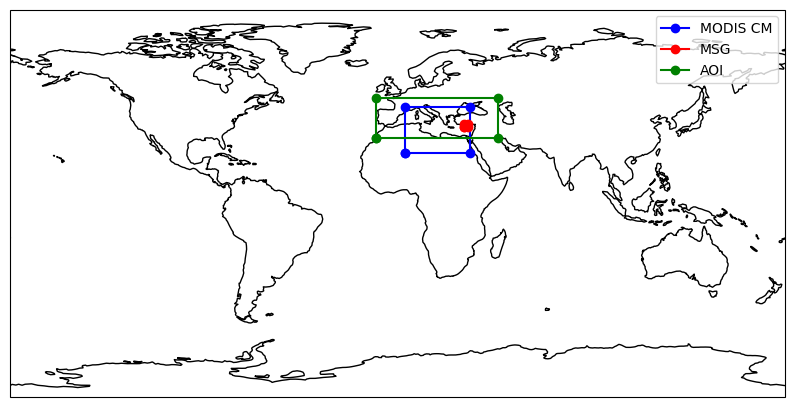

In [172]:
#plot the bounds of the modis image and the msg image on a universal map
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
# Plot MODIS bounds
modis_bounds = [[lonmin_modis, latmin_modis], [lonmax_modis, latmin_modis], [lonmax_modis, latmax_modis], [lonmin_modis, latmax_modis], [lonmin_modis, latmin_modis]]
ax.plot(*zip(*modis_bounds), color='blue', marker='o', transform=ccrs.PlateCarree(), label='MODIS CM')
# Plot MSG bounds
msg_bounds = [[xmin_msg, ymin_msg], [xmax_msg, ymin_msg], [xmax_msg, ymax_msg], [xmin_msg, ymax_msg], [xmin_msg, ymin_msg]]
ax.plot(*zip(*msg_bounds), color='red', marker='o', transform=ccrs.PlateCarree(), label='MSG')

aoi_bounds =  [[aoi_lon_min, aoi_lat_min], [aoi_lon_max, aoi_lat_min], [aoi_lon_max, aoi_lat_max], [aoi_lon_min, aoi_lat_max], [aoi_lon_min, aoi_lat_min]]
ax.plot(*zip(*aoi_bounds), color='green', marker='o', transform=ccrs.PlateCarree(), label='AOI')

plt.legend()
plt.show()

In [115]:
aoi_lat_min = 30.22889
aoi_lat_max = 49.012224
aoi_lon_min = -10.019531
aoi_lon_max = 46.617188

In [122]:
list(cm_df.name)

['MYD35_L2.A2022271.1130.061.2022272152616..tif',
 'MYD35_L2.A2023243.1445.061.2023244152616..tif',
 'MYD35_L2.A2021244.1255.061.2021245151242..tif',
 'MYD35_L2.A2020256.1120.061.2020257150247..tif',
 'MYD35_L2.A2021236.1340.061.2021237191801..tif',
 'MYD35_L2.A2021210.0945.061.2021210195653..tif',
 'MYD35_L2.A2022195.0940.061.2022319114543..tif',
 'MYD35_L2.A2024212.1330.061.2024213160438..tif',
 'MYD35_L2.A2024229.1150.061.2024230150231..tif',
 'MYD35_L2.A2024242.1400.061.2024243150526..tif',
 'MYD35_L2.A2024248.1445.061.2024249172714..tif',
 'MYD35_L2.A2024264.1405.061.2024265151134..tif',
 'MYD35_L2.A2021256.1135.061.2021257183248..tif',
 'MYD35_L2.A2023231.0945.061.2023231234748..tif',
 'MYD35_L2.A2023236.1450.061.2023237194858..tif',
 'MYD35_L2.A2022168.1145.061.2022316011851..tif',
 'MYD35_L2.A2020260.1100.061.2020261151438..tif',
 'MYD35_L2.A2021241.1220.061.2021242151336..tif',
 'MYD35_L2.A2021205.1425.061.2021206152712..tif',
 'MYD35_L2.A2021255.1235.061.2021256154338..tif',


In [166]:
i = 122

In [170]:
modis_file = list(cm_df.name)
i += 5
modis_im = rioxarray.open_rasterio(os.path.join(modis_cm_path, modis_file[i])).squeeze()
lonmax_modis, lonmin_modis = modis_im.x.max().item(), modis_im.x.min().item()
latmax_modis, latmin_modis = modis_im.y.max().item(), modis_im.y.min().item()

In [171]:
i

132

### MSG geoprocessed reprojection

In [ ]:
ref_nat_file = '/mnt/outputs/L1b/MSG4-SEVI-MSG15-0100-NA-20210601232742.451000000Z-NA.nat'
scn = Scene(reader="seviri_l1b_native", filenames=[ref_nat_file])
datasets = scn.available_dataset_names()
scn.load(datasets[1:], generate=False)
dataset = scn['IR_016']
crs_wkt = dataset.attrs['area'].crs_wkt

def reproject_msg_image(image, crs_wkt, ref_nat_file = '/mnt/outputs/L1b/MSG4-SEVI-MSG15-0100-NA-20210601232742.451000000Z-NA.nat'):
    import pyproj

    if crs_wkt is None:
        scn = Scene(reader="seviri_l1b_native", filenames=[ref_nat_file])
        datasets = scn.available_dataset_names()
        scn.load(datasets[1:], generate=False)
        dataset = scn['IR_016']
        crs_wkt = dataset.attrs['area'].crs_wkt

    # Define the source CRS from the WKT string
    source_crs = pyproj.CRS(crs_wkt)
    target_crs = 'EPSG:4326' # Global lat-lon coordinate system
    # copy dataset
    new_dataset = image.copy(deep=True)

    # assign CRS to dataarray
    new_dataset = new_dataset.rio.write_crs(source_crs, inplace=False)
    try:
        new_dataset = new_dataset.drop('acq_time') # Drop acq_time coordinate, which was causing issues # NOTE: Not sure why this is necessary?
    except:
        i = 2
    new_dataset = new_dataset.rio.reproject(target_crs)
    return new_dataset

In [253]:
reprojected = reproject_msg_image(msg_im)

/home/sgirtsou/miniconda3/envs/rs_tools/lib/python3.11/site-packages/satpy/cf/coords.py:201: UserWarning: Cannot pretty-format "acq_time" coordinates because they are not identical among the given datasets
  _warn_if_pretty_but_not_unique(pretty, coord_name)
/tmp/ipykernel_110319/1436145580.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  new_dataset = new_dataset.drop('acq_time') # Drop acq_time coordinate, which was causing issues # NOTE: Not sure why this is necessary?


In [372]:
def clip_and_align(msg_reprojected, modis_reprojected):
    modis_reprojected = modis_reprojected.fillna(0)
    modis_interp = modis_reprojected.interp(x = msg_reprojected.x, y = msg_reprojected.y, method = 'nearest')
    valid3d = modis_interp.notnull()                      # True where not-NaN
    mask2d = valid3d.isel(band=0, drop=True).astype(bool)   # (y, x)
    mask3d = mask2d.expand_dims(band=msg_reprojected['band']) 
    msg_clipped = msg_reprojected.Rad.where(mask3d, drop=True)
    modis_clipped = modis_interp.where(valid3d, drop=True) 
    return(msg_clipped, modis_clipped)


In [373]:
msg_clipped, modis_clipped = clip_and_align(reprojected, modis_im)

In [375]:
msg_clipped

<xarray.DataArray 'Rad' (band: 11, y: 341, x: 803)> Size: 12MB
array([[[ 3.2126095 ,  3.7441928 ,  3.905979  , ...,  3.6979682 ,
          3.7210805 ,  3.7210805 ],
        [ 4.7149096 ,  4.576236  ,  4.5531235 , ...,  3.836642  ,
          3.8828666 ,  3.8828666 ],
        [ 5.1771555 ,  4.8766956 ,  5.431391  , ...,  3.9753158 ,
          4.0215406 ,  4.0215406 ],
        ...,
        [12.180182  , 12.180182  , 12.15707   , ...,         nan,
                 nan,         nan],
        [12.226407  , 12.203295  , 12.226407  , ...,         nan,
                 nan,         nan],
        [12.226407  , 12.249519  , 12.295744  , ...,         nan,
                 nan,         nan]],

       [[ 0.63294935,  0.67319477,  0.71344006, ...,  0.10976002,
          0.10610133,  0.10610133],
        [ 0.78661335,  0.7683201 ,  0.8232001 , ...,  0.098784  ,
          0.098784  ,  0.10244268],
        [ 0.85978675,  0.8488108 ,  0.90734947, ...,  0.098784  ,
          0.09512535,  0.09512535],
...
        [ 3.726514  ,  3.726514  ,  3.6932414 , ...,         nan,
                 nan,         nan],
        [ 3.7597864 ,  3.7597864 ,  3.726514  , ...,         nan,
                 nan,         nan],
        [ 3.734832  ,  3.74315   ,  3.734832  , ...,         nan,
                 nan,         nan]],

       [[13.517689  , 13.401823  , 13.363201  , ...,  5.368454  ,
          5.329832  ,  5.329832  ],
        [13.594933  , 13.440445  , 13.556311  , ...,  4.943612  ,
          4.90499   ,  4.7891245 ],
        [13.672176  , 13.517689  , 13.556311  , ...,  4.6732583 ,
          4.6732583 ,  4.6732583 ],
        ...,
        [16.68469   , 16.607447  , 16.568825  , ...,         nan,
                 nan,         nan],
        [16.607447  , 16.530203  , 16.530203  , ...,         nan,
                 nan,         nan],
        [16.568825  , 16.491581  , 16.530203  , ...,         nan,
                 nan,         nan]]], dtype=float32)
Coordinates:
  * x            (x) float64 6kB 0.9508 0.9876 1.024 1.061 ... 30.33 30.36 30.4
  * y            (y) float64 3kB 42.63 42.59 42.55 42.52 ... 30.21 30.18 30.14
  * band         (band) <U6 264B 'IR_016' 'IR_039' ... 'WV_062' 'WV_073'
    spatial_ref  int64 8B 0
Attributes: (12/14)
    calibration:              radiance
    end_time:                 2020-09-29 12:15:00
    georef_offset_corrected:  true
    modifiers:                []
    orbital_parameters:       {"projection_longitude": 0.0, "projection_latit...
    platform_name:            Meteosat-11
    ...                       ...
    sensor:                   seviri
    standard_name:            toa_outgoing_radiance_per_unit_wavenumber
    start_time:               2020-09-29 12:00:00
    time_parameters:          {"nominal_start_time": "2020-09-29 12:00:00", "...
    units:                    mW m-2 sr-1 (cm-1)-1
    wavelength:               1.64 µm (1.5-1.78 µm)

In [376]:
msg_clipped.rio.to_raster('msg_clipped.tif')
modis_clipped.to_netcdf('modis_clipped.nc')

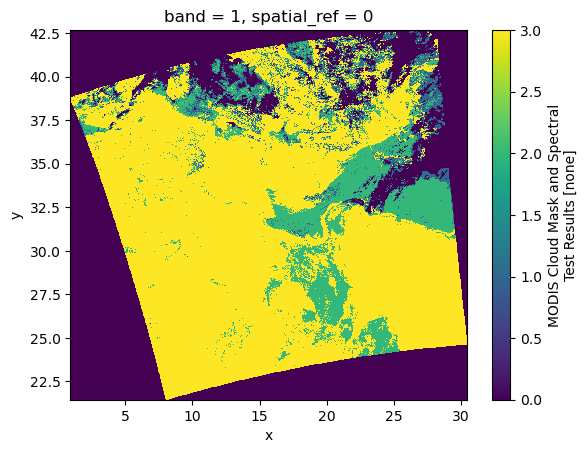

In [255]:
modis_im.plot()

In [330]:
modis_im = modis_im.fillna(0)

In [344]:
modis_im.to_netcdf('modis_wgs84.nc')
reprojected.to_netcdf('seviri_wgs84.nc')

In [321]:
modis_interp = modis_im.interp(x = reprojected.x, y = reprojected.y, method = 'nearest')

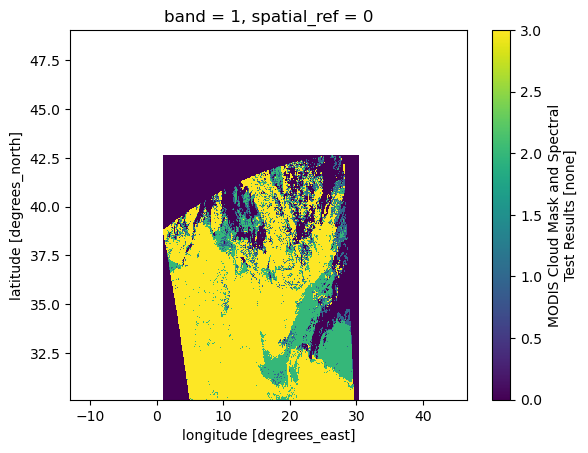

In [331]:
modis_interp.plot()

In [324]:
reprojected['cm_modis'] = modis_interp

In [335]:
reprojected

<xarray.Dataset> Size: 111MB
Dimensions:             (x: 1626, y: 515, band: 11)
Coordinates:
  * x                   (x) float64 13kB -13.0 -12.97 -12.93 ... 46.63 46.67
  * y                   (y) float64 4kB 49.02 48.98 48.94 ... 30.21 30.18 30.14
  * band                (band) <U6 264B 'IR_016' 'IR_039' ... 'WV_062' 'WV_073'
    spatial_ref         int64 8B 0
Data variables:
    msg_seviri_fes_3km  int64 8B ...
    Rad                 (band, y, x) float32 37MB nan nan nan ... nan nan nan
    cm_modis            (band, y, x) float64 74MB nan nan nan ... nan nan nan
Attributes:
    calibration:         radiance
    standard_name:       toa_outgoing_radiance_per_unit_wavenumber
    platform_name:       Meteosat-11
    sensor:              seviri
    units:               mW m-2 sr-1 (cm-1)-1
    orbital_parameters:  {"projection_longitude": 0.0, "projection_latitude":...

In [353]:
valid3d = modis_interp.notnull()                      # True where not-NaN
reprojected_masked = reprojected.Rad.where(valid3d, drop=True) 

In [358]:
mask2d = valid3d.isel(band=0, drop=True).astype(bool)   # (y, x)
mask3d = mask2d.expand_dims(band=msg_im['band'])        # (band:11, y, x)
print(mask3d.shape)

(11, 515, 1626)


In [366]:
reprojected.Rad.where(mask3d, drop=True)

<xarray.DataArray 'Rad' (band: 11, y: 341, x: 803)> Size: 12MB
array([[[ 3.2126095 ,  3.7441928 ,  3.905979  , ...,  3.6979682 ,
          3.7210805 ,  3.7210805 ],
        [ 4.7149096 ,  4.576236  ,  4.5531235 , ...,  3.836642  ,
          3.8828666 ,  3.8828666 ],
        [ 5.1771555 ,  4.8766956 ,  5.431391  , ...,  3.9753158 ,
          4.0215406 ,  4.0215406 ],
        ...,
        [12.180182  , 12.180182  , 12.15707   , ...,         nan,
                 nan,         nan],
        [12.226407  , 12.203295  , 12.226407  , ...,         nan,
                 nan,         nan],
        [12.226407  , 12.249519  , 12.295744  , ...,         nan,
                 nan,         nan]],

       [[ 0.63294935,  0.67319477,  0.71344006, ...,  0.10976002,
          0.10610133,  0.10610133],
        [ 0.78661335,  0.7683201 ,  0.8232001 , ...,  0.098784  ,
          0.098784  ,  0.10244268],
        [ 0.85978675,  0.8488108 ,  0.90734947, ...,  0.098784  ,
          0.09512535,  0.09512535],
...
        [ 3.726514  ,  3.726514  ,  3.6932414 , ...,         nan,
                 nan,         nan],
        [ 3.7597864 ,  3.7597864 ,  3.726514  , ...,         nan,
                 nan,         nan],
        [ 3.734832  ,  3.74315   ,  3.734832  , ...,         nan,
                 nan,         nan]],

       [[13.517689  , 13.401823  , 13.363201  , ...,  5.368454  ,
          5.329832  ,  5.329832  ],
        [13.594933  , 13.440445  , 13.556311  , ...,  4.943612  ,
          4.90499   ,  4.7891245 ],
        [13.672176  , 13.517689  , 13.556311  , ...,  4.6732583 ,
          4.6732583 ,  4.6732583 ],
        ...,
        [16.68469   , 16.607447  , 16.568825  , ...,         nan,
                 nan,         nan],
        [16.607447  , 16.530203  , 16.530203  , ...,         nan,
                 nan,         nan],
        [16.568825  , 16.491581  , 16.530203  , ...,         nan,
                 nan,         nan]]], dtype=float32)
Coordinates:
  * x            (x) float64 6kB 0.9508 0.9876 1.024 1.061 ... 30.33 30.36 30.4
  * y            (y) float64 3kB 42.63 42.59 42.55 42.52 ... 30.21 30.18 30.14
  * band         (band) <U6 264B 'IR_016' 'IR_039' ... 'WV_062' 'WV_073'
    spatial_ref  int64 8B 0
Attributes: (12/14)
    calibration:              radiance
    end_time:                 2020-09-29 12:15:00
    georef_offset_corrected:  true
    modifiers:                []
    orbital_parameters:       {"projection_longitude": 0.0, "projection_latit...
    platform_name:            Meteosat-11
    ...                       ...
    sensor:                   seviri
    standard_name:            toa_outgoing_radiance_per_unit_wavenumber
    start_time:               2020-09-29 12:00:00
    time_parameters:          {"nominal_start_time": "2020-09-29 12:00:00", "...
    units:                    mW m-2 sr-1 (cm-1)-1
    wavelength:               1.64 µm (1.5-1.78 µm)

In [347]:
modis_masked = modis_interp.where(valid3d, drop=True) 

In [367]:
modis_masked

<xarray.DataArray (band: 1, y: 341, x: 803)> Size: 2MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
  * x            (x) float64 6kB 0.9508 0.9876 1.024 1.061 ... 30.33 30.36 30.4
  * y            (y) float64 3kB 42.63 42.59 42.55 42.52 ... 30.21 30.18 30.14
Attributes: (12/23)
    ancillary_variables:         []
    area:                        Area ID: my_area\nDescription: Gloxx bal deg...
    Cell_Across_Swath_Sampling:  [1, 1354, 1]
    Cell_Along_Swath_Sampling:   [1, 2030, 1]
    description:                 \n                                          ...
    end_time:                    2020-09-29 12:10:00
    ...                          ...
    units:                       none
    valid_range:                 [0, -1]
    _satpy_id:                   DataID(name='cloud_mask', resolution=1000, m...
    _FillValue:                  0
    scale_factor:                1.0
    add_offset:                  0.0

In [ ]:
lonmax_modis, lonmin_modis = modis_im.x.max().item(), modis_im.x.min().item()
latmax_modis, latmin_modis = modis_im.y.max().item(), modis_im.y.min().item()

ymax_msg, ymin_msg = reprojected.y.values.max(), reprojected.y.values.min()
xmax_msg,xmin_msg = reprojected.x.values.max(), reprojected.x.values.min()